In [ ]:

!pip install --upgrade torch sentence-transformers

  Using cached torch-2.12.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cublas-13.1.1.3-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached cuda_bindings-13.3.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.7.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime-13.0.96-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# Warnings ko ignore karne ke liye
warnings.filterwarnings('ignore')

# Plots ka style aur size set karne ke liye
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
import pandas as pd

# Path se 'dataset/' hata diya hai kyunki file direct content ke andar hai
df = pd.read_csv('cleaned_resumeJD_pairs.csv')

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['match_label'].value_counts())

df.head(3)

Loaded: 320 rows, 4 columns
Columns: ['resume_text', 'job_description', 'match_score', 'match_label']

Label distribution:
match_label
High      115
Medium    105
Low       100
Name: count, dtype: int64


,resume_text,job_description,match_score,match_label
0,"ARCHIT KUMAR SAVITA\nKanpur, Uttar Pradesh, In...",Machine Learning Engineer Python Scikit-learn ...,57,Medium
1,Sample Resume Software Engineer Applicant 1,Data Scientist SQL Python Engineering Analytic...,63,High
2,Sample Resume Software Engineer Applicant 2,Full Stack Developer React Node.js Express Mon...,58,High


In [5]:
print('Loading the bert model')
model=SentenceTransformer('all-mpnet-base-v2')

print("Model loaded!")
print(f"Model:all-mpnet-base-v2")
print(f"Parmaeters:22.7M")
print(f"Embed dims:768")
print(f"MAx tokens:{model.max_seq_length}")


Loading the bert model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!
Model:all-mpnet-base-v2
Parmaeters:22.7M
Embed dims:768
MAx tokens:384


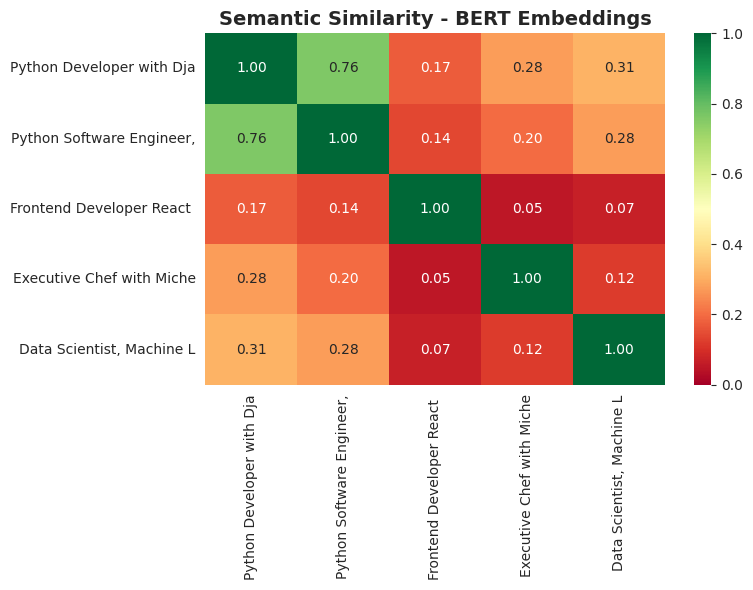

In [6]:
# #Part 2: Understanding Embeddings

texts = [
    "Python Developer with Django experience",
    "Python Software Engineer, Django REST APIs",
    "Frontend Developer React and JavaScript",
    "Executive Chef with Michelin experience",
    "Data Scientist, Machine Learning, PyTorch"
]

embeddings = model.encode(texts)
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=[t[:25] for t in texts],
            yticklabels=[t[:25] for t in texts],
            vmin=0, vmax=1)

plt.title('Semantic Similarity - BERT Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# #generating resume and jd embeddings
# We embed BOTH resume and job description separately

print("Generating resume embeddings...")
resume_embeddings = model.encode(
    df['resume_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nGenerating job description embeddings...")
jd_embeddings = model.encode(
    df['job_description'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embeddings shape: {resume_embeddings.shape}")
print(f"JD embeddings shape:     {jd_embeddings.shape}")
print(f"Each text={resume_embeddings.shape[1]}.dimensional vector")

Generating resume embeddings...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Generating job description embeddings...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Resume embeddings shape: (320, 768)
JD embeddings shape:     (320, 768)
Each text=768.dimensional vector


In [8]:
# #Compute Cosine Similarity for Each Pair
# #For each row: similarity between that resume and its paired JD

pair_similarities = []
for i in range(len(resume_embeddings)):
    sim = cosine_similarity([resume_embeddings[i]], [jd_embeddings[i]])[0][0]
    pair_similarities.append(sim)

df['bert_similarity'] = pair_similarities

print("Cosine similarity computed for all pairs.")
print(df[['match_label', 'match_score', 'bert_similarity']].head(10))

Cosine similarity computed for all pairs.
  match_label  match_score  bert_similarity
0      Medium           57         0.464369
1        High           63         0.245849
2        High           58         0.257406
3         Low           77         0.318490
4      Medium           89         0.252959
5      Medium           80         0.278385
6        High           81         0.313922
7         Low           90         0.249475
8      Medium           81         0.251214
9      Medium           90         0.313311


In [9]:
# #Base Model Performance: How Good is BERT Out of the Box?

# Hamare score ko 100 se divide kiya hai taaki scale same ho jaye (e.g., 85 -> 0.85)
mae = mean_absolute_error(df['match_score'] / 100, df['bert_similarity'])
rmse = np.sqrt(mean_squared_error(df['match_score'] / 100, df['bert_similarity']))

print("Base BERT Model Performance (before fine-tuning)")
print("=" * 50)
print(f"  MAE:  {mae:.4f}  (lower is better)")
print(f"  RMSE: {rmse:.4f}  (lower is better)")

Base BERT Model Performance (before fine-tuning)
  MAE:  0.4373  (lower is better)
  RMSE: 0.4582  (lower is better)


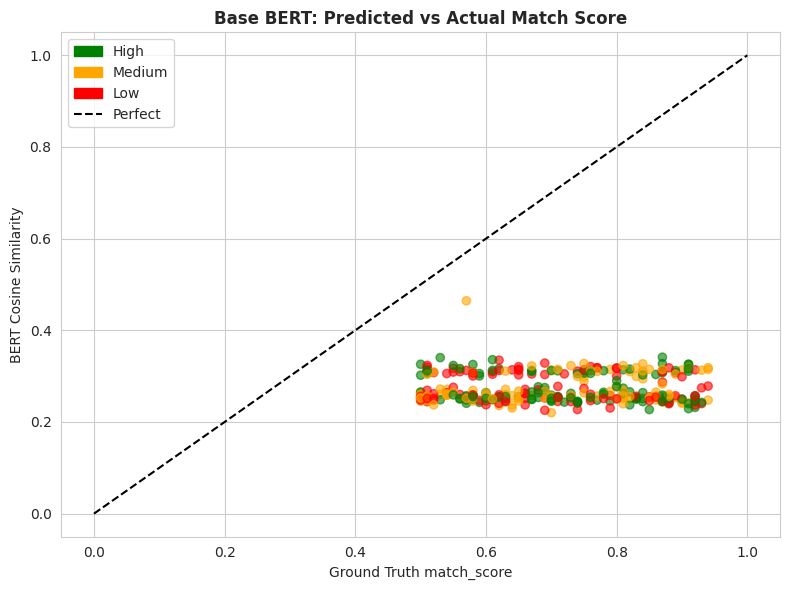

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# # Scatter: predicted vs ground truth
plt.figure(figsize=(8, 6))

# Case sensitivity match karne ke liye labels Capital letters mein map kiye hain
colors = df['match_label'].map({'Low': 'red', 'Medium': 'orange', 'High': 'green'})

# Ground truth score ko 100 se divide kiya taaki scale 0 se 1 ho jaye
plt.scatter(df['match_score'] / 100, df['bert_similarity'], c=colors, alpha=0.6)

# Perfect prediction wali diagonal line (0 se 1 tak)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect prediction')

plt.xlabel('Ground Truth match_score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT: Predicted vs Actual Match Score', fontweight='bold')

# Legend setup (Custom Patches)
legend_handles = [
    Patch(color='green', label='High'),
    Patch(color='orange', label='Medium'),
    Patch(color='red', label='Low'),
    Line2D([0], [0], color='black', linestyle='--', label='Perfect')
]
plt.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

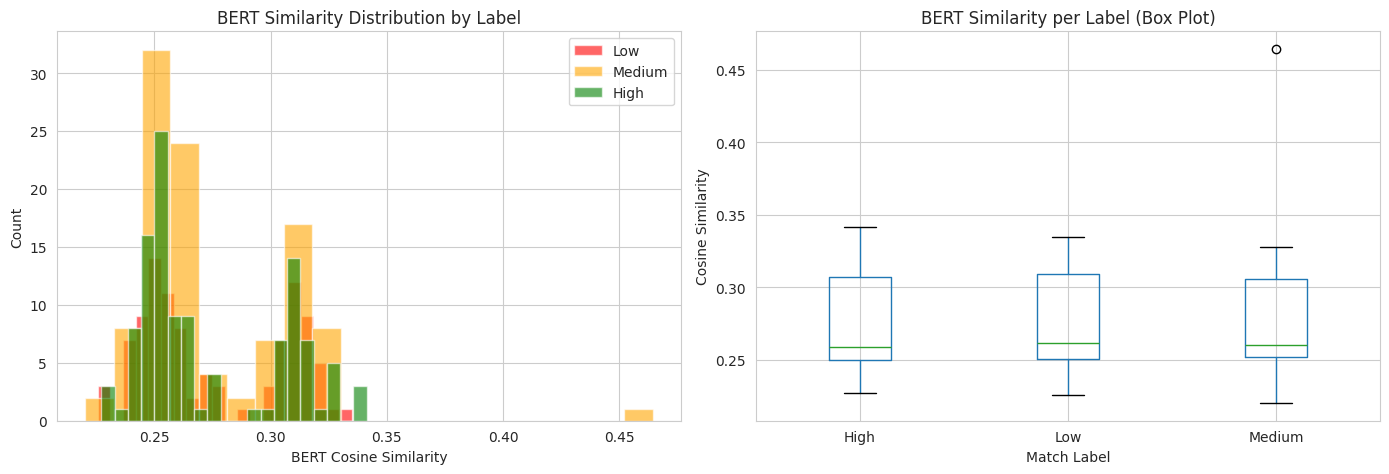


Overlap between labels = base model struggles to separate high vs low matches.
Goal of fine-tuning: push these distributions apart!


In [11]:
import matplotlib.pyplot as plt

# #Similarity Distribution by Label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: BERT similarity grouped by label
# Case sensitivity fix: 'Low', 'Medium', 'High' Capitalize kar diye hain
for label, color in [('Low', 'red'), ('Medium', 'orange'), ('High', 'green')]:
    subset = df[df['match_label'] == label]['bert_similarity']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color)

axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribution by Label')
axes[0].legend()

# Box plot
df.boxplot(column='bert_similarity', by='match_label',
           positions=[0, 1, 2], ax=axes[1])
axes[1].set_title('BERT Similarity per Label (Box Plot)')
axes[1].set_xlabel('Match Label')
axes[1].set_ylabel('Cosine Similarity')

plt.suptitle('')  # Default top title ko clear karne ke liye
plt.tight_layout()
plt.show()

# If the distributions overlap heavily, base model can't distinguish
# low vs high matches well - this is WHY we need to fine-tune
print("\nOverlap between labels = base model struggles to separate high vs low matches.")
print("Goal of fine-tuning: push these distributions apart!")

In [12]:
import pickle

# Embeddings aur labels ko dictionary format mein pickle file mein save karna
with open('resume_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'resume_embeddings': resume_embeddings,
        'jd_embeddings': jd_embeddings,
        'match_scores': df['match_score'].tolist(),
        'match_labels': df['match_label'].tolist()
    }, f)

print("Saved: resume_embeddings.pkl")
print(f"  resume_embeddings: {resume_embeddings.shape}")
print(f"  jd_embeddings:     {jd_embeddings.shape}")
print()
print("These will be loaded for fine-tuning.")

Saved: resume_embeddings.pkl
  resume_embeddings: (320, 768)
  jd_embeddings:     (320, 768)

These will be loaded for fine-tuning.
